In [85]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [86]:
# Number of sample per class
n_samples = 100

# class 0
class0 = torch.randn(n_samples,2) + torch.tensor([-2.0, -2.0])
# Class 1
class1 = torch.randn(n_samples, 2) + torch.tensor([2.0, 2.0])

# Combine features
X = torch.cat((class0, class1), dim=0)

# Create labels
y = torch.cat((
    torch.zeros(n_samples),
    torch.ones(n_samples)
)).reshape(-1, 1)

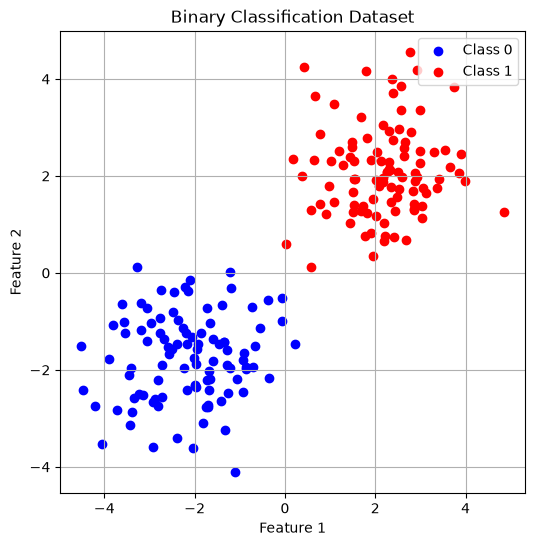

In [87]:
plt.figure(figsize=(6,6))

plt.scatter(class0[:,0], class0[:,1], color='blue', label='Class 0')
plt.scatter(class1[:,0], class1[:,1], color='red', label='Class 1')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.legend()
plt.grid(True)

plt.show()

In [88]:
# Data set is ready.
X.shape, y.shape

(torch.Size([200, 2]), torch.Size([200, 1]))

In [89]:
# Now weight initialization
inp_size = X.shape[1]  # 2
W = torch.randn(inp_size,1, requires_grad=True)
b = torch.randn(1,requires_grad=True)
print("Random weight for two input features",W[0].item(),W[1].item())
print("Random bias",b.item())

Random weight for two input features -1.600385069847107 0.8983902335166931
Random bias -0.6497360467910767


In [94]:
# The logistic regression is Sigmoid of Linear Regression
# So linear regression : z = w*x +b

z = torch.matmul(X,W) + b
print(z[:5])

tensor([[-0.9934],
        [-2.5788],
        [-1.4406],
        [-0.6184],
        [ 3.4392]], grad_fn=<SliceBackward0>)


In [95]:
# Now convert these continous values to 0 and 1
def Sigmoid(x):
    return 1 / (1 + torch.exp(-x))

In [96]:
y_pred = Sigmoid(z)
y_pred[:5]

tensor([[0.2702],
        [0.0705],
        [0.1915],
        [0.3501],
        [0.9689]], grad_fn=<SliceBackward0>)

In [97]:
# Lets verify for the first record.
print(z[0])
1 / (1 + 2.7182818284590452353602874713527**(-1.5836))

tensor([-0.9934], grad_fn=<SelectBackward0>)


0.8297137616916845

# BCE Loss 
### BCE Loss - BCE is actually measuring Confidence + Correctness
### We don't just care whether the prediction is correct. We also care how confident the model was.

### Suppose two doctors A and B; A says I am 51% sure that patient have diabetes, Dr B says he's 99% sure patient has diabetes. And patient actually has diabetes. So in this case the Dr B should be rewarded more, and vice versa.

### Now why Logarithm
Binary Cross Entropy (BCE) is the standard loss function used for binary classification problems, where the true label (y) is either 0 or 1, and the model predicts a probability y_hat between 0 and 1. It measures how closely the predicted probability matches the actual class while strongly penalizing confident but incorrect predictions.

The BCE loss for a single sample is given by:

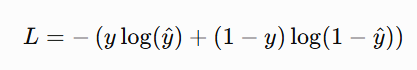

where:

* y is the ground truth label (0 or 1).
* y_hat is the predicted probability of the positive class.

The term (y*log(y_hat)) is active only when the true class is 1, encouraging the model to assign a high probability to the positive class. 
Similarly, the term ((1-y)*log(1-y_hat)) is active only when the true class is 0, encouraging the model to assign a high probability to the negative class. The logarithm increases the penalty as the predicted probability for the correct class decreases, making the model learn from highly confident incorrect predictions. The negative sign ensures that the loss remains non-negative, allowing the optimization algorithm to minimize it during training.

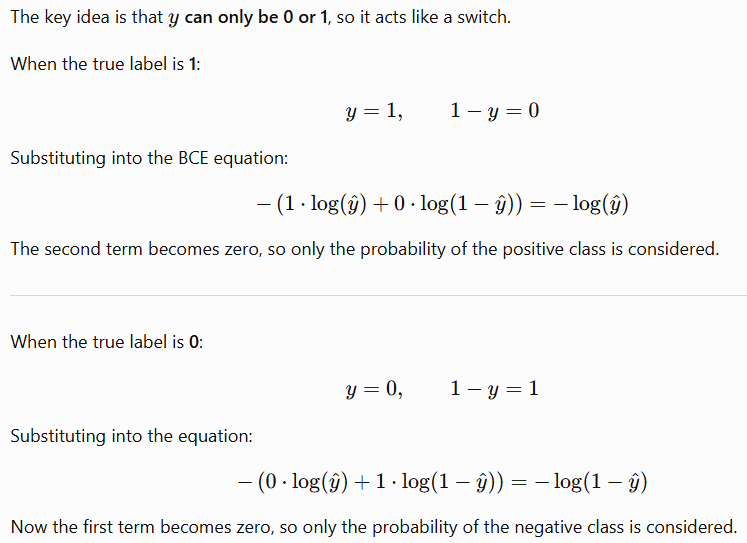

In [99]:
def Binary_Cross_Entropy(y, y_pred):
    epsilon = 1e-7
    y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)

    loss = -(y * torch.log(y_pred) +
             (1 - y) * torch.log(1 - y_pred))

    return loss.mean()

### epsilon because when the value of y_pred will 1; the log(1-y_pred) = log(0) i.e infinity and hence training stops. 
### y_pred = torch.clamp(y_pred, 1e-7, 1 - 1e-7)
### 0.0  → 0.0000001
### 1.0  → 0.9999999

In [100]:
torch.clamp(torch.tensor(0),1e-7, 1-1e-7).item(), torch.clamp(torch.tensor(1),1e-7, 1-1e-7).item()

(1.0000000116860974e-07, 0.9999998807907104)

In [101]:
def SGD(W, b, lr):
    with torch.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad

    W.grad.zero_()
    b.grad.zero_()

    return W, b

## Training Loop

In [102]:
lr = 0.01
for epoch in range(5000):

    z = torch.matmul(X,W) + b
    y_pred = Sigmoid(z)
    loss = Binary_Cross_Entropy(y,y_pred)
    loss.backward()
    W,b = SGD(W,b,lr)
    pred = (y_pred >= 0.5).float()

    accuracy = (pred == y).float().mean()

    if epoch%500==0:
        print(f"Epoch: {epoch} Loss: {loss.item()} Accuracy: {accuracy}")


Epoch: 0 Loss: 2.1054561138153076 Accuracy: 0.18000000715255737
Epoch: 500 Loss: 0.050857748836278915 Accuracy: 0.9950000047683716
Epoch: 1000 Loss: 0.028907157480716705 Accuracy: 1.0
Epoch: 1500 Loss: 0.021559853106737137 Accuracy: 1.0
Epoch: 2000 Loss: 0.01776748336851597 Accuracy: 1.0
Epoch: 2500 Loss: 0.01540841069072485 Accuracy: 1.0
Epoch: 3000 Loss: 0.01377788558602333 Accuracy: 1.0
Epoch: 3500 Loss: 0.012571736238896847 Accuracy: 1.0
Epoch: 4000 Loss: 0.011636234819889069 Accuracy: 1.0
Epoch: 4500 Loss: 0.010884854011237621 Accuracy: 1.0


# Writing Everything using Class

In [103]:
class Sigmoid:
    def __call__(self, x):
        return 1 / (1 + torch.exp(-x))

class SGD:
    def __init__(self, params, lr=0.01):
        self.params = params
        self.lr = lr

    def step(self):
        with torch.no_grad():
            for param in self.params:
                param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            param.grad.zero_()
        
class BCE:

    def __call__(self, y, y_pred):
        epsilon = 1e-7
        y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
        loss = -(y * torch.log(y_pred) + (1 - y) * torch.log(1 - y_pred))
        return loss.mean()
        

class LogisticRegression:

    def __init__(self, input_dim):
        self.w = torch.randn(input_dim, 1, requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)
        self.sigmoid = Sigmoid()

    def forward(self, x):
        z = x @ self.w + self.b
        return self.sigmoid(z)

    def predict(self, x):
        prob = self.forward(x)
        return (prob >= 0.5).float()

    def params(self):
        return [self.w, self.b[0]]


In [105]:
model = LogisticRegression(input_dim=2)
criterion = BCE()
optimizer = SGD([model.w, model.b], lr=0.01)

for epoch in range(2001):
    y_pred = model.forward(X)
    loss = criterion(y, y_pred)
    pred = (y_pred >= 0.5).float()
    accuracy = (pred == y).float().mean()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} Loss: {loss.item()} Accuracy: {accuracy}")

Epoch: 0 Loss: 4.080037593841553 Accuracy: 0.02500000037252903
Epoch: 100 Loss: 0.39300185441970825 Accuracy: 0.824999988079071
Epoch: 200 Loss: 0.14384891092777252 Accuracy: 0.9850000143051147
Epoch: 300 Loss: 0.08955370634794235 Accuracy: 0.9950000047683716
Epoch: 400 Loss: 0.06652335822582245 Accuracy: 1.0
Epoch: 500 Loss: 0.05376848578453064 Accuracy: 1.0
Epoch: 600 Loss: 0.04563218727707863 Accuracy: 1.0
Epoch: 700 Loss: 0.03996770828962326 Accuracy: 1.0
Epoch: 800 Loss: 0.0357825867831707 Accuracy: 1.0
Epoch: 900 Loss: 0.032554637640714645 Accuracy: 1.0
Epoch: 1000 Loss: 0.029982594773173332 Accuracy: 1.0
Epoch: 1100 Loss: 0.02788035199046135 Accuracy: 1.0
Epoch: 1200 Loss: 0.026126563549041748 Accuracy: 1.0
Epoch: 1300 Loss: 0.024638688191771507 Accuracy: 1.0
Epoch: 1400 Loss: 0.023358602076768875 Accuracy: 1.0
Epoch: 1500 Loss: 0.022244106978178024 Accuracy: 1.0
Epoch: 1600 Loss: 0.021263865754008293 Accuracy: 1.0
Epoch: 1700 Loss: 0.02039402537047863 Accuracy: 1.0
Epoch: 1800 

In [106]:
model.params()

[tensor([[0.8577],
         [2.0640]], requires_grad=True),
 tensor(-0.1474, grad_fn=<SelectBackward0>)]

In [112]:
X[5],y[5],model.predict(X[5])

(tensor([-2.3925, -3.4036]), tensor([0.]), tensor([0.]))

In [113]:
X[-5],y[-5],model.predict(X[-5])

(tensor([1.9538, 0.3543]), tensor([1.]), tensor([1.]))